In [ ]:
import numpy as np

import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
import pandas as pd
from matplotlib import pyplot as plt

from causal_graph_comparison.dim_reduction import subsample_outputs
from causal_graph_comparison import *

from climatem.data_loader.causal_datamodule import CausalClimateDataModule
import torch


In [121]:
N_MODES = 4
TAU_MAX = 5
LAT = 40
LON = 40
N_SAMPLES = 995

In [122]:
# Step 1: Load the data
mlp_output = np.load("../outputs/test_results-mlp-savar.npz")

In [123]:
outputs = mlp_output["outputs"]
targets = mlp_output["target"]
inputs = mlp_output["inputs"]

print("MLP output shape: ", outputs.shape)
print("MLP target shape: ", targets.shape)
print("MLP inputs shape: ", inputs.shape)


MLP output shape:  (50, 1600)
MLP target shape:  (50, 1600)
MLP inputs shape:  (5, 1600)


In [124]:
# Spatial subsampling of outputs for dimensionality reduction
subsampled_outputs = subsample_outputs(outputs, N_MODES)
subsampled_targets = subsample_outputs(targets, N_MODES)

Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)


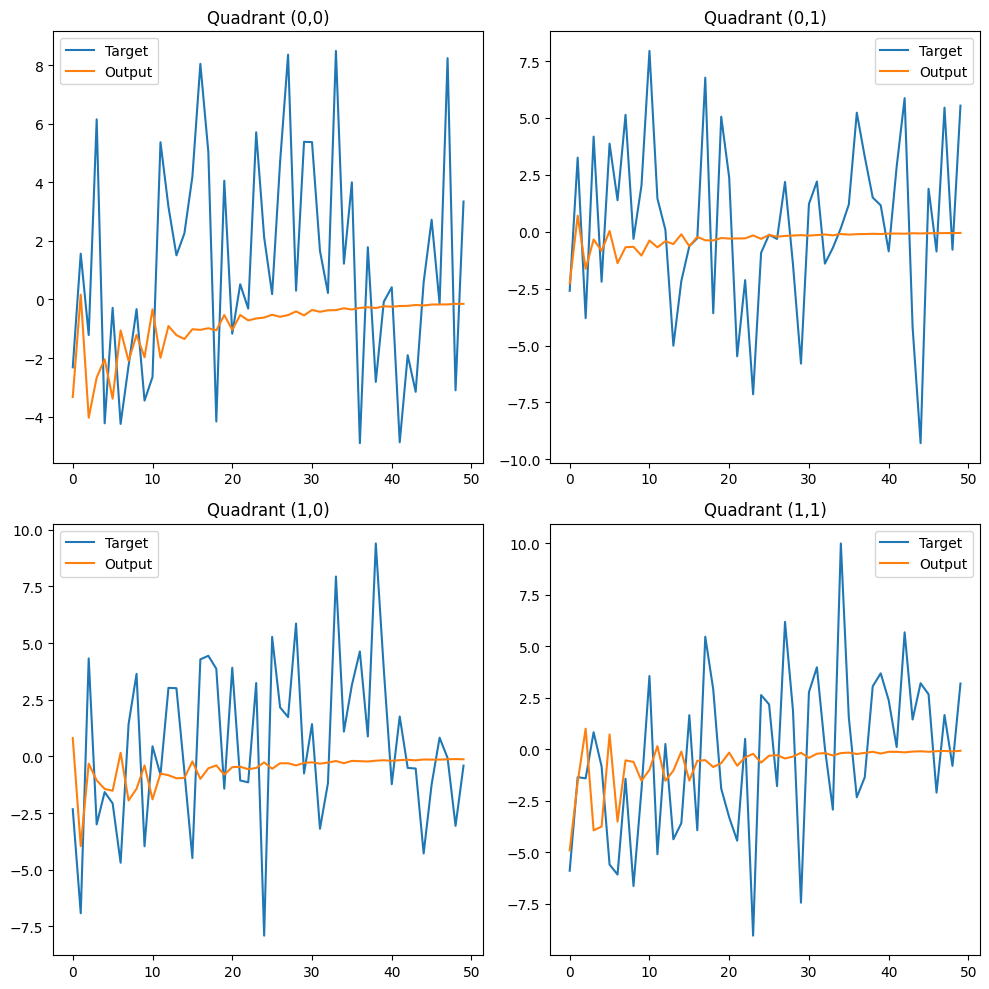

Subsampled targets shape:  (50, 2, 2)
Subsampled outputs shape:  (50, 2, 2)


In [102]:
# Plot targets and outputs for all 4 quadrants
plt.figure(figsize=(10, 10))

for i in range(2):
    for j in range(2):
        plt.subplot(2, 2, i*2 + j + 1)
        test_targets = subsampled_targets[:, i, j]
        test_outputs = subsampled_outputs[:, i, j]
        
        plt.plot(test_targets, label="Target")
        plt.plot(test_outputs, label="Output")
        plt.title(f"Quadrant ({i},{j})")
        plt.legend()

plt.tight_layout()
plt.show()

print("Subsampled targets shape: ", subsampled_targets.shape)
print("Subsampled outputs shape: ", subsampled_outputs.shape)


In [103]:
subsampled_gt = subsample_outputs(target_array, N_MODES)

Subsampled shape:  (999, 2, 2)


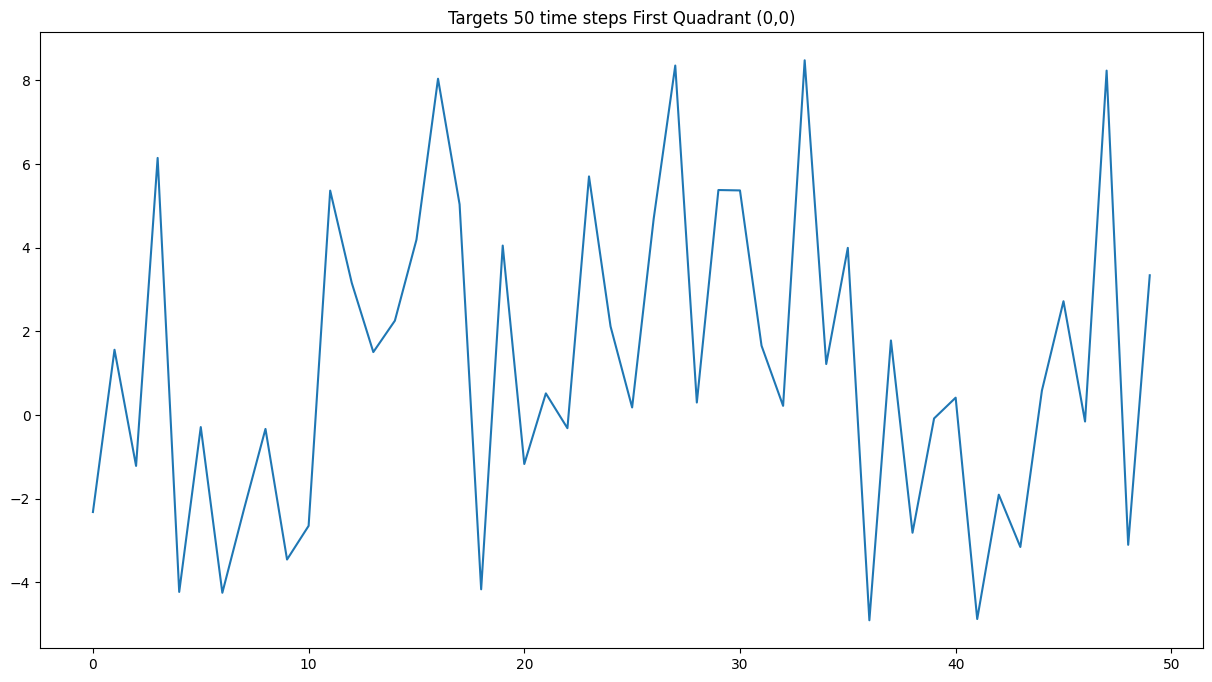

In [126]:
# Plot ground truth data for one quadrant
plt.figure(figsize=(15, 8))
targets_to_plot = subsampled_targets[:, 0, 0]  # First quadrant
plt.plot(targets_to_plot)
plt.title("Targets 50 time steps First Quadrant (0,0)")
plt.show()



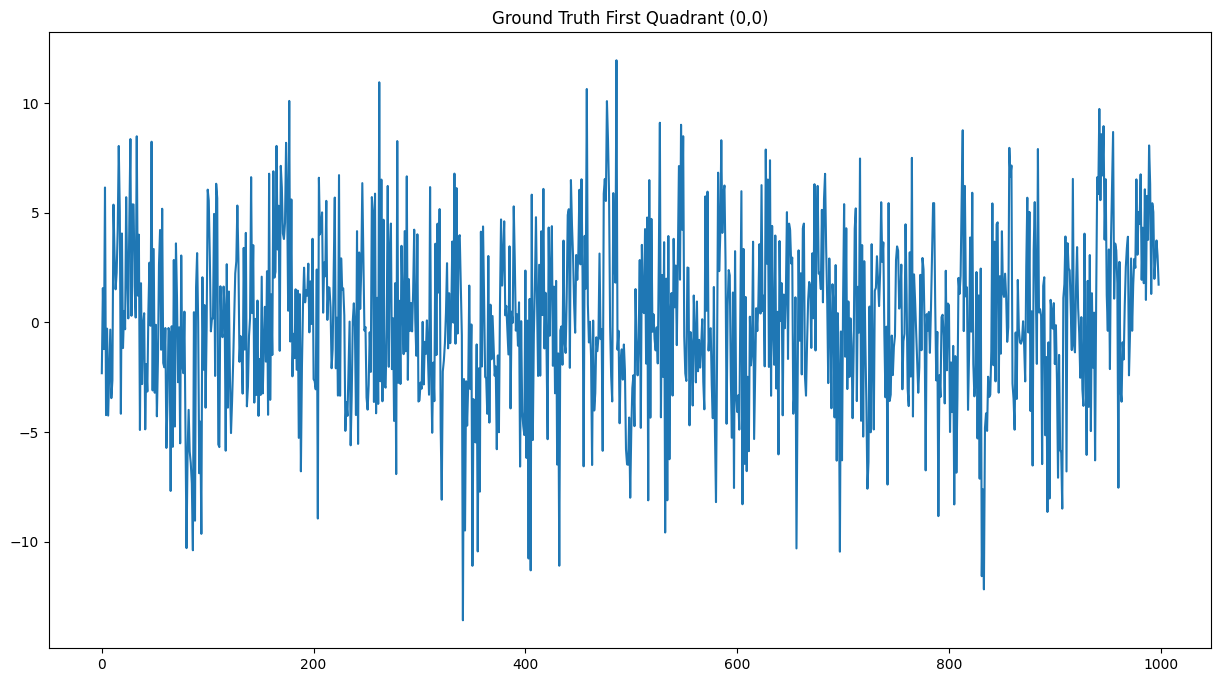

Subsampled ground truth shape:  (999, 2, 2)


In [104]:
# Plot ground truth data for one quadrant
plt.figure(figsize=(15, 8))
gt_data = subsampled_gt[:, 0, 0]  # First quadrant
plt.plot(gt_data)
plt.title("Ground Truth First Quadrant (0,0)")
plt.show()

print("Subsampled ground truth shape: ", subsampled_gt.shape)



In [112]:
# STEP 4: Learn causal graph using PCMCI+

# flatten the data
subsampled_outputs = subsampled_outputs.reshape(subsampled_outputs.shape[0], -1)
subsampled_targets = subsampled_targets.reshape(subsampled_targets.shape[0], -1)
subsampled_gt = subsampled_gt.reshape(subsampled_gt.shape[0], -1)

# Create variable names for the modes
var_names = [f"mode_{i}" for i in range(N_MODES)]
dataframe = pp.DataFrame(subsampled_targets, var_names=var_names)

# Initialize PCMCI+
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(),
    verbosity=2
)

# Run PCMCI+
results = pcmci.run_pcmci(
    tau_max=TAU_MAX,  # Maximum time lag
    tau_min=1,
    pc_alpha=0.05  # Significance level #TODO
)

n_gt_connections = 8 # TODO: get this from the GT causal graph in parameters csv file

# Extract results
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Variable mode_0

Iterating through pc_alpha = [0.05]:

# pc_alpha = 0.05 (1/1):

Testing condition sets of dimension 0:

    Link (mode_0 -1) -?> mode_0 (1/20):
    Subset 0: () gives pval = 0.96903 / val =  0.006
    Non-significance detected.

    Link (mode_0 -2) -?> mode_0 (2/20):
    Subset 0: () gives pval = 0.21559 / val =  0.200
    Non-significance detected.

    Link (mode_0 -3) -?> mode_0 (3/20):
    Subset 0: () gives pval = 0.48045 / val =  0.115
    Non-significance detected.

    Link (mode_0 -4) -?> mode_0 (4/20):
    Subset 0: () gives pval = 0.25837 / val =  0.183
    Non-significance detected.

    Link (mode_0 -5) -?> mode_0 (5/20):
    Subset 0: () gives pval = 0.66957 / val = -0.070
    Non-significance detected.

    Link (mode_1 -1) -?> mode_0 (6/20):
    Subset 0: () g

In [113]:
print("graph:", graph)

# 0. Value matrix before flattening
print("val_matrix shape: ", val_matrix.shape)
# print("val_matrix: ", results["val_matrix"]) # partial correlations between all variables at all lags

# 1. Flatten the value matrix to get all values
all_values = val_matrix.flatten()  # Shape: (n_vars * n_vars * tau_max)
print("all_values shape: ", all_values.shape)

# 2. Sort values in descending order (strongest first)
sorted_indices = all_values.argsort()[::-1]  # Indices of strongest to weakest
print("sorted_indices: ", sorted_indices[:n_gt_connections - 1])
print("sorted values: ", all_values[sorted_indices[:20]])

# 3. Get the 8th strongest value (since n_gt_connections = 8)
threshold_value = np.abs(all_values[sorted_indices[n_gt_connections - 1]])  # 8th position (index 7)
print("threshold_value: ", threshold_value)

# # 4. Remove all links weaker than this threshold
# graph[val_matrix < threshold_value] = ""
# print("graph shape: ", graph.shape)

# print("graph: ", graph)

# Get indices of top K strongest links (by absolute value)
abs_values = np.abs(val_matrix)
top_k_indices = np.unravel_index(
    abs_values.flatten().argsort()[-n_gt_connections:], 
    abs_values.shape
)

# Create new graph with only top K links
new_graph = np.full_like(graph, "")
for i, j, tau in zip(*top_k_indices):
    new_graph[i, j, tau] = graph[i, j, tau]

graph = new_graph
print("graph: ", graph)

graph: [[['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']]

 [['' '-->' '' '-->' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']]

 [['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '-->' '' '']]

 [['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']]]
val_matrix shape:  (4, 4, 6)
all_values shape:  (96,)
sorted_indices:  [93 65 37  4 23 71 13]
sorted values:  [0.28344198 0.28311953 0.28165223 0.23602453 0.22021491 0.21366686
 0.19580283 0.19182137 0.16819595 0.16015472 0.14182141 0.12966632
 0.11730526 0.11297426 0.10347034 0.10294567 0.09594614 0.09586199
 0.09414064 0.0922542 ]
threshold_value:  0.19182136758067553
graph:  [[['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']]

 [['' '-->' '' '-->' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']]

 [['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '

In [114]:

print(f"\nPCMCI+ Results:")
print(f"Graph shape: {graph.shape}")
print(f"Value matrix shape: {val_matrix.shape}")
print(f"P-value matrix shape: {p_matrix.shape}")

# Print the discovered links
print(f"\nDiscovered causal links:")
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX):
            if graph[i, j, tau] != "":
                print(f"{var_names[i]} <-{graph[i, j, tau]}- {var_names[j]} (lag {tau+1})")


PCMCI+ Results:
Graph shape: (4, 4, 6)
Value matrix shape: (4, 4, 6)
P-value matrix shape: (4, 4, 6)

Discovered causal links:
mode_1 <--->- mode_0 (lag 2)
mode_1 <--->- mode_0 (lag 4)
mode_2 <--->- mode_3 (lag 4)


In [115]:
# Step 5: Analyze mode relationships

print(f"\nStep 5: Analyzing mode relationships...")

# Calculate correlations between modes
correlations = np.corrcoef(subsampled_outputs.reshape(-1, 4).T)

print(f"\nCorrelation matrix between modes:")
print(pd.DataFrame(correlations, index=var_names, columns=var_names))

# Count causal links per mode
print(f"\nCausal link counts per mode:")
for i, mode in enumerate(var_names):
    incoming = np.sum(graph[i, :, :] != "")
    outgoing = np.sum(graph[:, i, :] != "")
    print(f"{mode}: {incoming} incoming, {outgoing} outgoing links")



Step 5: Analyzing mode relationships...

Correlation matrix between modes:
          mode_0    mode_1    mode_2    mode_3
mode_0  1.000000  0.713988  0.098794  0.341500
mode_1  0.713988  1.000000 -0.287587  0.546131
mode_2  0.098794 -0.287587  1.000000  0.066856
mode_3  0.341500  0.546131  0.066856  1.000000

Causal link counts per mode:
mode_0: 0 incoming, 2 outgoing links
mode_1: 2 incoming, 0 outgoing links
mode_2: 1 incoming, 0 outgoing links
mode_3: 0 incoming, 1 outgoing links


In [116]:
val_matrix = results["val_matrix"].copy()

val_matrix[results["val_matrix"] < threshold_value] = 0

print("val_matrix: ", val_matrix)

val_matrix:  [[[0.         0.         0.         0.         0.23602453 0.        ]
  [0.         0.         0.         0.         0.         0.        ]
  [0.         0.19580283 0.         0.         0.         0.19182137]
  [0.         0.         0.         0.         0.         0.22021491]]

 [[0.         0.         0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.        ]
  [0.         0.28165223 0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.        ]]

 [[0.         0.         0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.28311953]
  [0.         0.         0.         0.         0.         0.21366686]]

 [[0.         0.         0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.        ]
 

In [66]:
results["val_matrix"].min()

-0.37465993199047526


Step 6: Plotting causal graph...


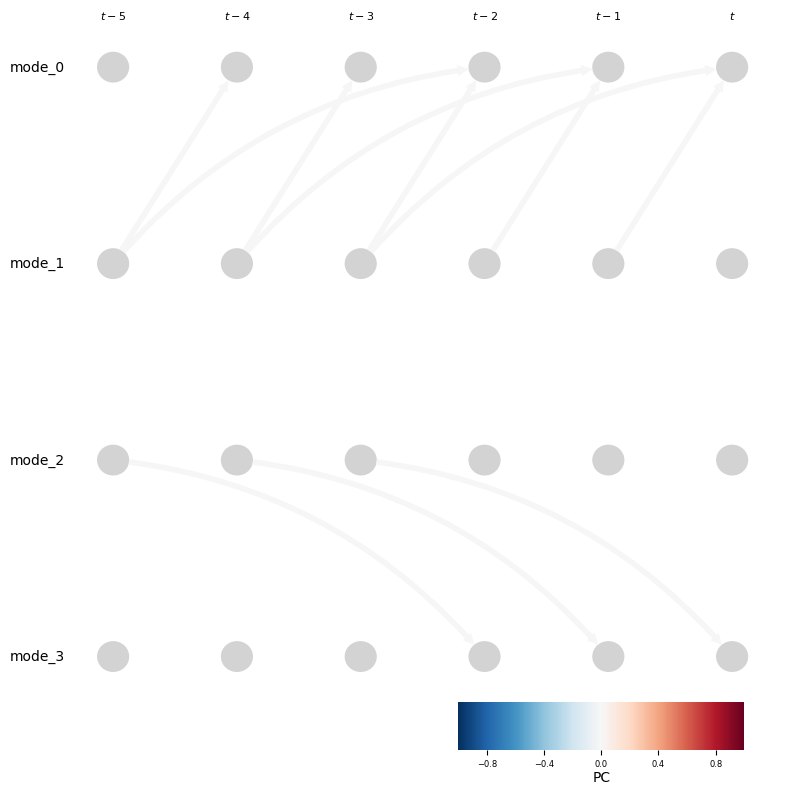

In [117]:
# Step 6: Plot causal graph
print(f"\nStep 6: Plotting causal graph...")

# Plot graph for each lag
tp.plot_time_series_graph(
    graph = graph,
    val_matrix=val_matrix,
    figsize=(8, 8),
    node_size=0.05,
    var_names=var_names,
    link_colorbar_label='PC')

plt.tight_layout()
# plt.savefig("causal_graph_example.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [21]:
# Test settings
TEST_BATCH_SIZE = 1
NO_ACCEL = False
SEED = 1
FUTURE_TIMESTEPS = 1
ROLLOUT_TIMESTEPS = 50
LONGITUDE = 40
LATITUDE = 40
TAU = 5
LAYERS = [1600, 800, 1600]
INPUT_SIZE = LATITUDE * LONGITUDE * TAU
OUTPUT_SIZE = LATITUDE * LONGITUDE * FUTURE_TIMESTEPS

# Load data
dl = CausalClimateDataModule(
    # Required parameters for ClimateDataModule
    in_var_ids=["savar"],
    out_var_ids=["savar"],  # Same as input for SAVAR
    train_years="2015-2100",
    train_historical_years="1950-2014",
    test_years="2015-2100",  # Same as train for SAVAR
    val_split=0.1,  # 10% validation split
    seq_to_seq=True,
    channels_last=False,
    train_scenarios=["savar"],
    test_scenarios=["savar"],
    train_models="savar",
    eval_batch_size=64,
    num_workers=0,
    pin_memory=False,
    load_train_into_mem=True,
    load_test_into_mem=True,
    verbose=True,
    seed=42,
    seq_len=12,
    data_dir="",  # Not used for SAVAR
    output_save_dir=f"{SCRATCH_DIR}/data/SAVAR_DATA_TEST",
    num_ensembles=1,
    lon=LONGITUDE,
    lat=LATITUDE,
    num_levels=1,
    global_normalization=True,
    seasonality_removal=False,
    reload_climate_set_data=True,
    # Required parameters for CausalClimateDataModule
    tau=TAU,
    future_timesteps=FUTURE_TIMESTEPS,
    num_months_aggregated=1,
    train_val_interval_length=100,
    # SAVAR specific parameters
    time_len=10000,
    comp_size=10,
    noise_val=0.2,
    n_per_col=2,
    difficulty="med_easy",
    seasonality=False,
)

dl.setup()

test_dataset = dl._data_val

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)

Test models: None
TEST SET NAMES ['ssp370_NorESM2-LM', 'ssp126_NorESM2-LM']
2015-2100
1950-2014
Getting causal data [mode=train+val] ...
Loaded data shape: (1600, 10000)
Loaded data shape after: (10000, 40, 40)
data is float32
Trying to regrid to lon, lat if we have regular data...
intervallength100
datashape10000
train: float32


In [23]:
data, target = next(iter(test_loader))
print(data.shape)
print(target.shape)

torch.Size([1, 5, 1, 1600])
torch.Size([1, 1, 1, 1600])


In [24]:
target_list = []
for i, (data, target) in enumerate(test_loader):
        target_list.append(target.squeeze().cpu().numpy())

target_array = np.array(target_list)

print(target_array.shape)

(999, 1600)
